<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/MEG_HES004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2004i2 — 2D Shape-Memory Map in (λ, m)
# ============================================================

# --- Lattice parameters ---
N = 512
L = 50.0
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)

# --- Time parameters ---
dt = 0.002
steps = 6000
t_final = steps * dt

# --- Physical parameters (fixed except λ, m) ---
A = 1.0
sigma = 1.2
k0 = 1.5

# --- Precompute FFT wave numbers (k) ---
k = 2*np.pi * np.fft.fftfreq(N, d=dx)

# --- Initial packet (fixed across scan) ---
psi0 = A * np.exp(-(x**2)/(2*sigma**2)) * np.cos(k0 * x)

# --- Helper functions ---
def compute_width(field):
    norm = np.sum(field**2)
    mean = np.sum(x * field**2) / norm
    var = np.sum((x - mean)**2 * field**2) / norm
    return np.sqrt(var)

def compute_coherence(field, ref):
    num = np.abs(np.sum(field * ref))
    den = np.sqrt(np.sum(field**2) * np.sum(ref**2))
    return num / den

def evolve_and_measure(lam, m, steps=steps, dt=dt):
    """
    For given (λ, m):
      - evolve psi starting from fixed psi0
      - return final coherence, width, peak, and final psi(x)
    """
    psi = psi0.copy()
    for step in range(steps):
        # Nonlinear step
        psi_nl = psi - dt * lam * psi**3

        # Linear step via FFT (m-dependent dispersion)
        psi_k = np.fft.fft(psi_nl)
        psi_k *= np.exp(-0.5j * (k**2 / m) * dt)
        psi = np.real(np.fft.ifft(psi_k))

    C_final = compute_coherence(psi, psi0)
    width_final = compute_width(psi)
    peak_final = np.max(np.abs(psi))
    return C_final, width_final, peak_final, psi

print("Core QFT2004i2 definitions loaded.")


Core QFT2004i2 definitions loaded.


In [ ]:
# ============================================================
# MEG_HES002 kernel — Δz_temporal for a given density
# ============================================================

def smooth_field(field, window):
    if window <= 1:
        return field.copy()
    kernel = np.ones(window) / window
    pad = window // 2
    padded = np.pad(field, pad, mode='reflect')
    smoothed = np.convolve(padded, kernel, mode='valid')
    return smoothed

def entanglement_map(rho, a):
    return rho / (1 + a * rho)

def curvature_load_field(rho_smooth, K, gamma):
    second_derivative = np.gradient(np.gradient(rho_smooth))
    return K * (np.abs(second_derivative) ** gamma)

def dz_temporal_for_density(density, a, K, gamma, smooth_window=33):
    density_smooth = smooth_field(density, smooth_window)
    E = entanglement_map(density, a)
    C = curvature_load_field(density_smooth, K, gamma)
    update_rate = 1.0 / (E + C + 1e-9)
    update_rate /= np.mean(update_rate)
    dz = np.max(update_rate) - np.min(update_rate)
    return dz

print("MEG_HES002 kernel ready (Δz_temporal for any 1D density).")


MEG_HES002 kernel ready (Δz_temporal for any 1D density).


In [ ]:
# ============================================================
# MEG_HES004 — Δz_temporal map over (λ, m)
# ============================================================

# Parameter grids (same as QFT2004i2)
lambda_values = np.linspace(0.0, 2.0, 9)   # 0.0 ... 2.0
m_values      = np.linspace(0.5, 2.0, 11)  # 0.5 ... 2.0

n_lam = len(lambda_values)
n_m   = len(m_values)

C_map     = np.zeros((n_lam, n_m))
width_map = np.zeros((n_lam, n_m))
peak_map  = np.zeros((n_lam, n_m))
Dz_map    = np.zeros((n_lam, n_m))

# Fixed MEG_HES002 parameters for this map
a_fixed     = 10.0
K_fixed     = 100.0
gamma_fixed = 0.6
smooth_window = 33

print("Running QFT2004i2 + Δz_temporal scan over (λ, m)...")
for i, lam in enumerate(lambda_values):
    for j, m_val in enumerate(m_values):
        C_final, w_final, p_final, psi_final = evolve_and_measure(lam, m_val)
        C_map[i, j]     = C_final
        width_map[i, j] = w_final
        peak_map[i, j]  = p_final

        density = np.abs(psi_final)  # density-like field
        dz = dz_temporal_for_density(
            density,
            a=a_fixed,
            K=K_fixed,
            gamma=gamma_fixed,
            smooth_window=smooth_window
        )
        Dz_map[i, j] = dz

        print(f"λ={lam:.3f}, m={m_val:.3f} | C={C_final:.4f}, width={w_final:.4f}, peak={p_final:.4f}, Δz={dz:.4f}")

print("Scan complete.")
print("Δz_temporal map ready.")


Running QFT2004i2 + Δz_temporal scan over (λ, m)...
λ=0.000, m=0.500 | C=0.9911, width=0.8121, peak=0.8612, Δz=29.7350
λ=0.000, m=0.650 | C=0.9963, width=0.7858, peak=0.9082, Δz=24.7511
λ=0.000, m=0.800 | C=0.9982, width=0.7711, peak=0.9355, Δz=13.0811
λ=0.000, m=0.950 | C=0.9991, width=0.7621, peak=0.9525, Δz=12.1527
λ=0.000, m=1.100 | C=0.9995, width=0.7563, peak=0.9636, Δz=15.3303
λ=0.000, m=1.250 | C=0.9997, width=0.7523, peak=0.9714, Δz=22.3589
λ=0.000, m=1.400 | C=0.9998, width=0.7494, peak=0.9769, Δz=16.9677
λ=0.000, m=1.550 | C=0.9999, width=0.7473, peak=0.9810, Δz=19.1641
λ=0.000, m=1.700 | C=0.9999, width=0.7457, peak=0.9841, Δz=16.6073
λ=0.000, m=1.850 | C=0.9999, width=0.7445, peak=0.9865, Δz=44.4515
λ=0.000, m=2.000 | C=0.9999, width=0.7435, peak=0.9884, Δz=28.7164
λ=0.250, m=0.500 | C=0.9566, width=1.1864, peak=0.3908, Δz=42.4193
λ=0.250, m=0.650 | C=0.9591, width=1.1678, peak=0.3941, Δz=33.5648
λ=0.250, m=0.800 | C=0.9592, width=1.1570, peak=0.3932, Δz=25.6746
λ=0.250, m

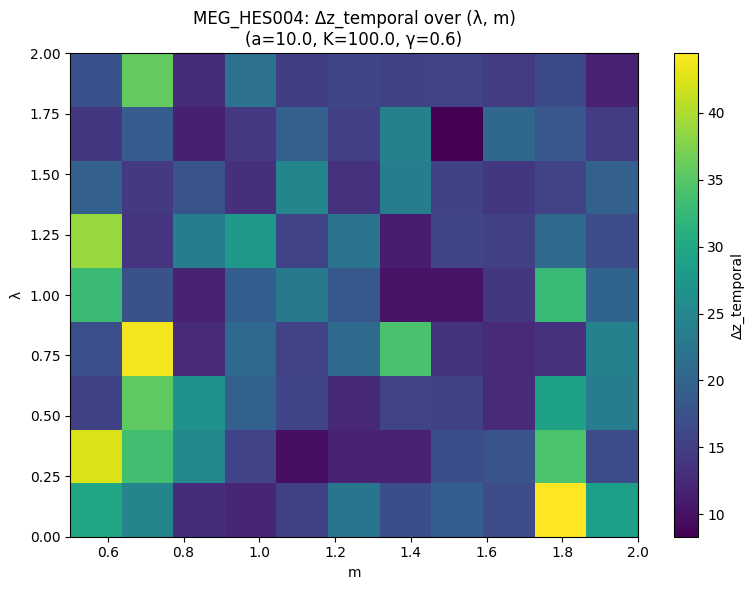

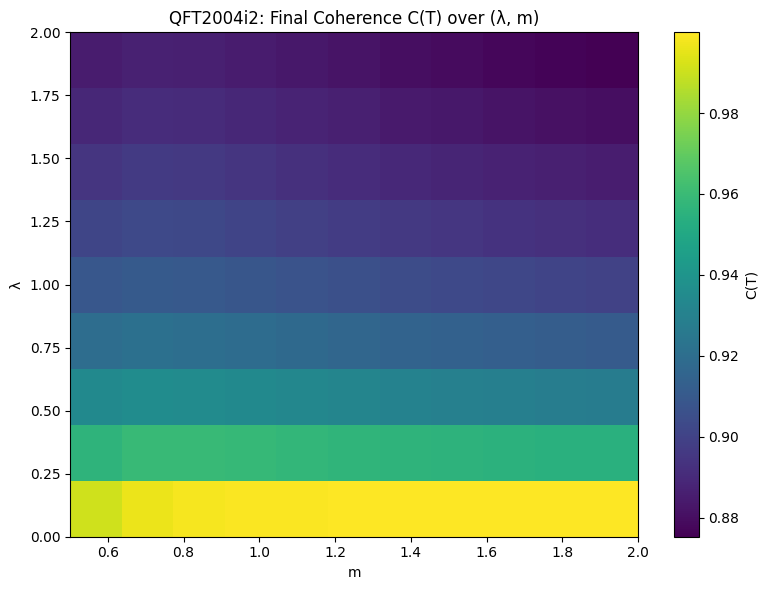


MEG_HES004 summary (extremes):
  Δz_min = 8.3212, Δz_max = 44.4515
  C_min  = 0.8753, C_max  = 0.9999
  width_min = 0.7435, width_max = 1.5136
  peak_min  = 0.1462, peak_max  = 0.9884


In [ ]:
def plot_heatmap(data, title, cbar_label):
    plt.figure(figsize=(8,6))
    im = plt.imshow(
        data,
        origin='lower',
        aspect='auto',
        extent=[m_values[0], m_values[-1], lambda_values[0], lambda_values[-1]]
    )
    plt.colorbar(im, label=cbar_label)
    plt.xlabel("m")
    plt.ylabel("λ")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Δz_temporal map
plot_heatmap(Dz_map,
             f"MEG_HES004: Δz_temporal over (λ, m)\n(a={a_fixed}, K={K_fixed}, γ={gamma_fixed})",
             "Δz_temporal")

# Coherence map for comparison
plot_heatmap(C_map,
             "QFT2004i2: Final Coherence C(T) over (λ, m)",
             "C(T)")

# Brief printed summary
print("\nMEG_HES004 summary (extremes):")
print(f"  Δz_min = {Dz_map.min():.4f}, Δz_max = {Dz_map.max():.4f}")
print(f"  C_min  = {C_map.min():.4f}, C_max  = {C_map.max():.4f}")
print(f"  width_min = {width_map.min():.4f}, width_max = {width_map.max():.4f}")
print(f"  peak_min  = {peak_map.min():.4f}, peak_max  = {peak_map.max():.4f}")


Lowest-Δz_temporal point:
  λ = 1.750
  m = 1.550
  Δz_temporal = 8.3212


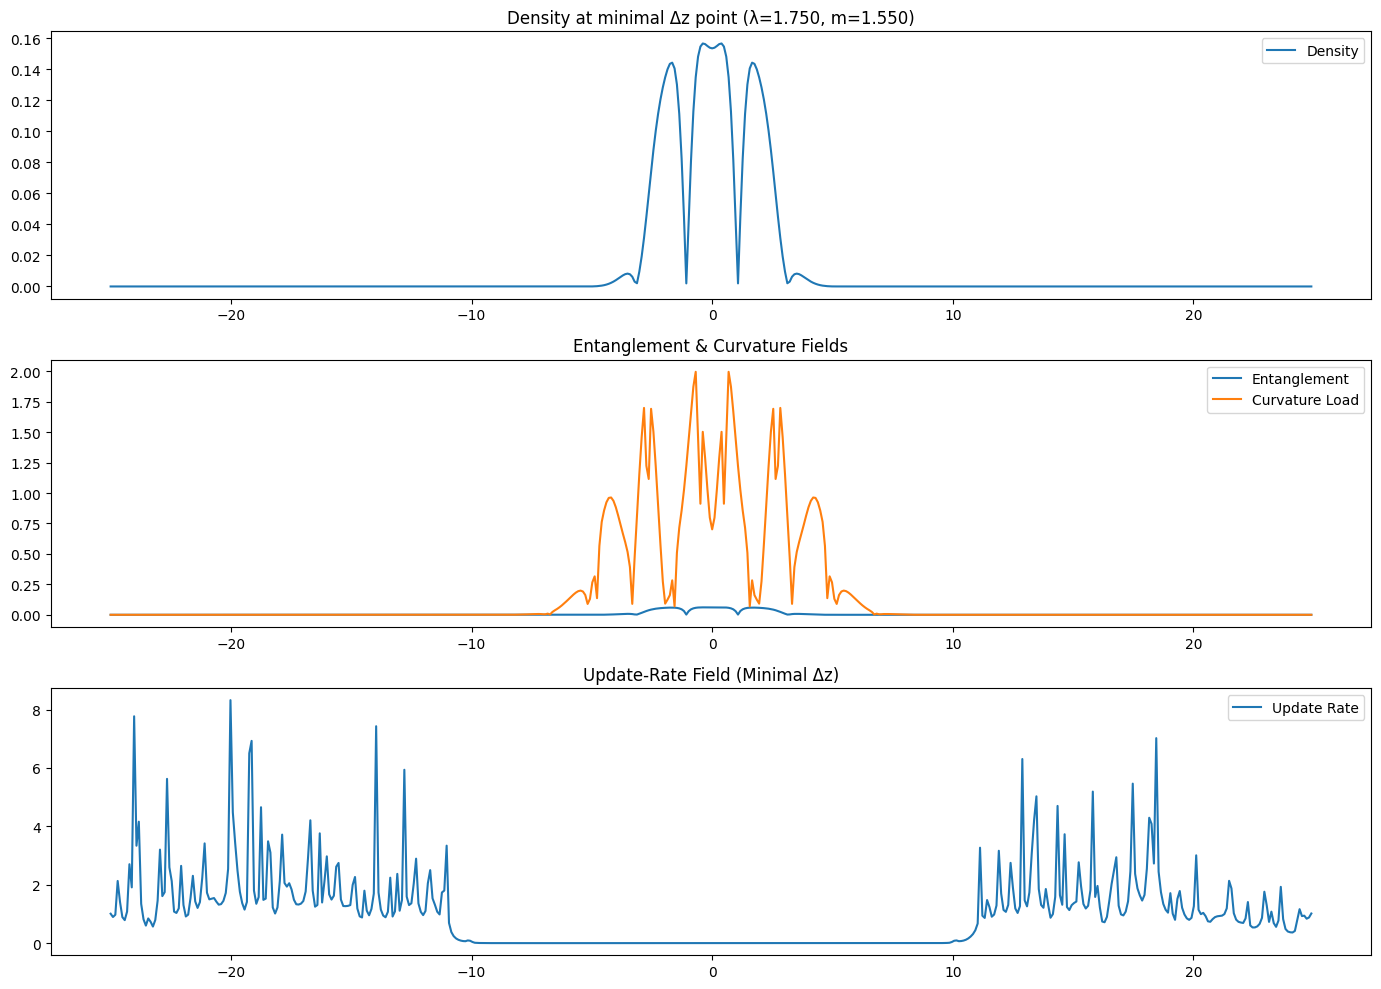

In [ ]:
# ============================================================
# Extract the (λ, m) point with minimal Δz_temporal
# ============================================================

# Find indices of minimum Δz
i_min, j_min = np.unravel_index(np.argmin(Dz_map), Dz_map.shape)

lam_min = lambda_values[i_min]
m_min   = m_values[j_min]
dz_min  = Dz_map[i_min, j_min]

print("Lowest-Δz_temporal point:")
print(f"  λ = {lam_min:.3f}")
print(f"  m = {m_min:.3f}")
print(f"  Δz_temporal = {dz_min:.4f}")

# Re-evolve that point to get the actual field
C_final, w_final, p_final, psi_final = evolve_and_measure(lam_min, m_min)

density = np.abs(psi_final)
density_smooth = smooth_field(density, smooth_window)

# Compute fields at this point
E = entanglement_map(density, a_fixed)
C = curvature_load_field(density_smooth, K_fixed, gamma_fixed)

update_rate = 1.0 / (E + C + 1e-9)
update_rate /= np.mean(update_rate)

# ============================================================
# Plot the fields for the minimal-Δz point
# ============================================================

plt.figure(figsize=(14, 10))

plt.subplot(3,1,1)
plt.plot(x, density, label="Density")
plt.title(f"Density at minimal Δz point (λ={lam_min:.3f}, m={m_min:.3f})")
plt.legend()

plt.subplot(3,1,2)
plt.plot(x, E, label="Entanglement")
plt.plot(x, C, label="Curvature Load")
plt.title("Entanglement & Curvature Fields")
plt.legend()

plt.subplot(3,1,3)
plt.plot(x, update_rate, label="Update Rate")
plt.title("Update-Rate Field (Minimal Δz)")
plt.legend()

plt.tight_layout()
plt.show()
